In [90]:
# importanto bibliotecas
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [ ]:
# importando dados
tabela_de_clientes = pd.read_csv("data_ecommerce_customer_churn.csv")
display(tabela_de_clientes)
tabela_de_clientes.shape

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


(3941, 11)

In [ ]:
# verificando valores nulos
tabela_de_clientes.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [ ]:
# verificando dados do dataframe
tabela_de_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [ ]:
# preenchimento dos valores nulos e nova verificação
tabela_de_clientes.fillna(0, inplace=True)
tabela_de_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3941 non-null   float64
 1   WarehouseToHome           3941 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3941 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [ ]:
# contagem de linhas com churn positivo
display(tabela_de_clientes['Churn'].value_counts())
display(tabela_de_clientes['Churn'].value_counts(normalize=True).map("{:.1%}".format))

Churn
0    3267
1     674
Name: count, dtype: int64

Churn
0    82.9%
1    17.1%
Name: proportion, dtype: object

In [ ]:
# visualização da proporção do churn através de gráfico
import plotly.express as px

coluna1 = 'Churn'
grafico = px.histogram(tabela_de_clientes, x=coluna1, color='Churn', width=750, )
grafico.show()

In [ ]:
# encodamento das colunas com dados do tipo string
transformador = ColumnTransformer(
    transformers=[
        ('encoder_sem_ordem', OneHotEncoder(drop='first', sparse_output=False, dtype=int), ['PreferedOrderCat', 'MaritalStatus'])
    ],
    remainder='passthrough')

In [ ]:
# nova tabela com dados encodados
tabela_transformada = transformador.fit_transform(tabela_de_clientes)

In [ ]:
# Novo dataframe
novas_colunas = transformador.get_feature_names_out()
tabela_final = pd.DataFrame(tabela_transformada, columns=novas_colunas)
tabela_final

,encoder_sem_ordem__PreferedOrderCat_Grocery,encoder_sem_ordem__PreferedOrderCat_Laptop & Accessory,encoder_sem_ordem__PreferedOrderCat_Mobile,encoder_sem_ordem__PreferedOrderCat_Mobile Phone,encoder_sem_ordem__PreferedOrderCat_Others,encoder_sem_ordem__MaritalStatus_Married,encoder_sem_ordem__MaritalStatus_Single,remainder__Tenure,remainder__WarehouseToHome,remainder__NumberOfDeviceRegistered,remainder__SatisfactionScore,remainder__NumberOfAddress,remainder__Complain,remainder__DaySinceLastOrder,remainder__CashbackAmount,remainder__Churn
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,15.0,29.0,4.0,3.0,2.0,0.0,7.0,143.32,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7.0,25.0,4.0,1.0,2.0,0.0,7.0,129.29,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,27.0,13.0,3.0,1.0,5.0,0.0,7.0,168.54,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,25.0,4.0,3.0,7.0,0.0,0.0,230.27,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,30.0,15.0,4.0,4.0,8.0,0.0,8.0,322.17,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3936,0.0,0.0,0.0,0.0,0.0,1.0,0.0,28.0,9.0,5.0,3.0,8.0,0.0,1.0,231.86,0.0
3937,0.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,7.0,2.0,2.0,4.0,0.0,4.0,157.80,0.0
3938,0.0,1.0,0.0,0.0,0.0,1.0,0.0,30.0,6.0,5.0,3.0,3.0,1.0,2.0,156.60,0.0
3939,0.0,0.0,1.0,0.0,0.0,1.0,0.0,6.0,0.0,4.0,3.0,10.0,1.0,0.0,124.37,1.0


In [ ]:
# Agrupamento dos previsores e da classe
X = tabela_final.iloc[:,0:15].values
y = tabela_final.iloc[:, 15].values


In [ ]:
# Divisão dos dados para treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=42)

In [ ]:
# Criação e teste do modelo Naive Bayes
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
# Previsões com Naive Bayes
previsoes = naive_bayes.predict(X_test)

In [ ]:
# Acurácia do modelo Naive Bayes
taxa_acertos = accuracy_score(y_test, previsoes)
taxa_acertos

0.7641589180050719

In [ ]:
# Matriz de confusão do modelo Naive Bayes
confusao = confusion_matrix(y_test, previsoes)
confusao

array([[759, 226],
       [ 53, 145]])

In [ ]:
# Criação e treino do modelo de Árvore de Decisão
arvore = DecisionTreeClassifier()
arvore.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
# Previsões com o modelo de Árvore de Decisão
previsoes2 = arvore.predict(X_test)

In [ ]:
# Acurácia do modelo de Árvore de Decisão
taxa_acertos2 = accuracy_score(previsoes2, y_test)
taxa_acertos2


0.907861369399831

In [ ]:
# Matriz de Confusão do modelo de Árvore de Decisão
confusao2 = confusion_matrix(y_test, previsoes2)
confusao2

array([[926,  59],
       [ 50, 148]])

In [99]:
import matplotlib.pyplot as plt

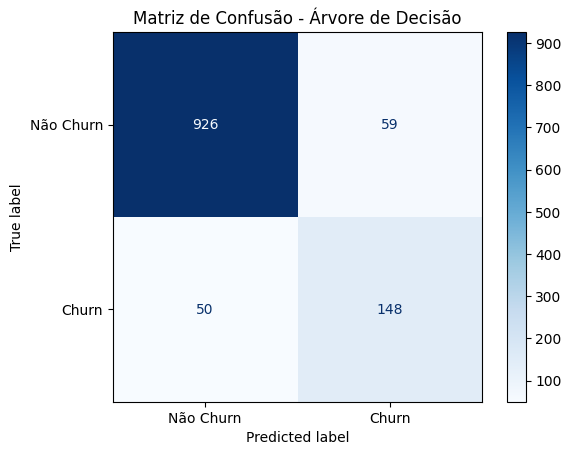

In [100]:
disp = ConfusionMatrixDisplay.from_estimator(
    arvore, 
    X_test,
    y_test,
    display_labels=['Não Churn', 'Churn'],
    cmap=plt.cm.Blues
)
disp.ax_.set_title("Matriz de Confusão - Árvore de Decisão")
plt.savefig('grafico.png', bbox_inches='tight', dpi=300)
plt.show()